# Customer Lifetime Value (CLV) - Proxy

This section estimates customer value using a practical proxy approach:
- Historical gross revenue per customer
- Expected value using average monthly retention rate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12-01


In [2]:
orders = (
    df.groupby("Invoice", as_index=False)
      .agg(
          OrderValue=("Revenue", "sum"),
          OrderDate=("InvoiceDate", "min"),
          CustomerID=("Customer ID", "first")
      )
)

orders.head()

,Invoice,OrderValue,OrderDate,CustomerID
0,489434,505.30,2009-12-01 07:45:00,13085.0
1,489435,145.80,2009-12-01 07:46:00,13085.0
2,489436,630.33,2009-12-01 09:06:00,13078.0
3,489437,310.75,2009-12-01 09:08:00,15362.0
4,489438,2286.24,2009-12-01 09:24:00,18102.0


In [3]:
customer = (
    orders.groupby("CustomerID", as_index=False)
          .agg(
              HistoricalRevenue=("OrderValue", "sum"),
              Orders=("Invoice", "nunique"),
              FirstOrder=("OrderDate", "min"),
              LastOrder=("OrderDate", "max")
          )
)

customer["AOV"] = customer["HistoricalRevenue"] / customer["Orders"]

customer.head()

,CustomerID,HistoricalRevenue,Orders,FirstOrder,LastOrder,AOV
0,12346.0,372.86,11,2009-12-14 08:34:00,2010-06-28 13:53:00,33.896364
1,12347.0,1323.32,2,2010-10-31 14:20:00,2010-12-07 14:57:00,661.660000
2,12348.0,222.16,1,2010-09-27 14:59:00,2010-09-27 14:59:00,222.160000
3,12349.0,2671.14,3,2010-04-29 13:20:00,2010-10-28 08:23:00,890.380000
4,12351.0,300.93,1,2010-11-29 15:23:00,2010-11-29 15:23:00,300.930000


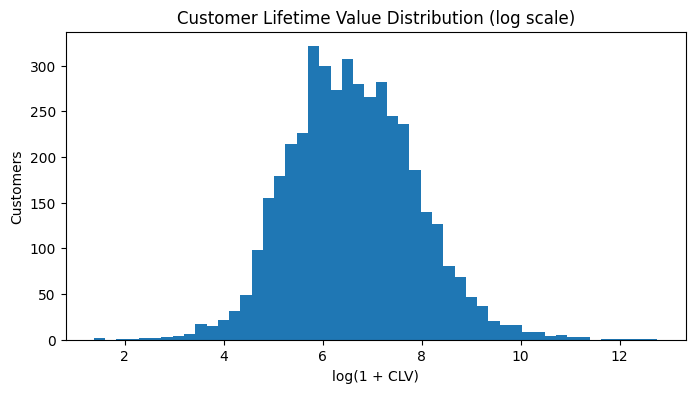

In [4]:
plt.figure(figsize=(8,4))

plt.hist(np.log1p(customer["HistoricalRevenue"]), bins=50)

plt.title("Customer Lifetime Value Distribution (log scale)")
plt.xlabel("log(1 + CLV)")
plt.ylabel("Customers")

plt.show()

In [5]:
customer_sorted = customer.sort_values("HistoricalRevenue", ascending=False)

customer_sorted["CumRevenueShare"] = (
    customer_sorted["HistoricalRevenue"].cumsum()
    / customer_sorted["HistoricalRevenue"].sum()
)

top_10 = int(len(customer_sorted) * 0.10)

customer_sorted.iloc[top_10]["CumRevenueShare"]

np.float64(0.5987317850715729)